#### Bluebird-Gymnasium Demo Notebook
A suite of gymnasium environments for air traffic control (ATC).
The environments are based on [Bluebird-ATC](https://github.com/project-bluebird/BluebirdATC) (an ATC simulator).

In [ ]:
%pip install bluebird-gymnasium matplotlib

### Imports

In [1]:
import random
import typing

from enum import Enum

import numpy as np
import IPython.display
import matplotlib.pyplot as plt

from bluebird_gymnasium.envs import BaseEnv, InfiniteEnv, SectorIEnv, SectorXEnv, SectorYEnv, SpringfieldEnv

### Introduction

#### Description
In air traffic control (ATC), an agent is given a defined region in the airspace to control (this is called a sector).
In this notebook, the supported sectors (defined as gymnasium environments) are I sector, Y sector, X sector, and Springfield sector.
The I, X and Y sectors are defined using the shape of the respective alphabets.
As the sectors are defined as gymnasium environments, they support the use of reinforcement learning or other types of agents that uses
the gymnasium API (i.e., `step` and `reset` methods).

For each environment, a configuration/config (`dict`) has been provided. In each config, the reward function, state space and action space
are defined. The use of the config allows for flexibility in adjusting each environment to either extend or remove from environment's
specification. Furthermore, the extensibility of the framework is hinged on the use of the configs. For example, if you add a new reward 
function and want to use it in an environment, it needs to be specified in the config.

#### Actions
In this notebook, supported actions for each aircraft are:
- Lateral actions
    - Turn left by 10 degrees
    - Turn right by 10 degrees
- Vertical actions
    - Go up (climb) by 10 flight levels
    - Go down (descend) by 10 flight levels
    - Go up or down to the exit flight level

By default, only the lateral actions have been enabled as the initial scenarios of focus will be on lateral control. For the complete list of
actions supported by the framework, please see the [action space docs](#).

#### Reward functions
The reward function is formulated as a multi-objective signal. Each individual object/component attempts to elicit specific behaviours from
the agent. The final reward value is a scalar signal that is derived from a weighted linear combination of all objectives. The weights allows
for the specification of the relative importance of each objective. Generally, the reward signal rewards/penalizes safe/unsafe aircraft control.
By default, the enabled reward objectives and the default weighting are:
- `position_status_const` (weight 1.0): penalizes the agent if it incorrectly controls an aircraft out of the sector.
- `lateral_centreline_distance_shaped` (weight 1.0): rewards the agent if it controls aircraft to stay on their defined route's centreline. Penalizes otherwise.
- `safety_simple_avoidance_exp` (weight 1.2): penalizes the agent if it lets any pair of aircraft come too close to each other (below the acceptable threshold: 5 nautical miles laterally and 10 flight levels vertically). Note that this reward function evaluates both the current time step and also predictions 5 minutes into the future. 

For the complete list of reward functions supported by the framework, please see the [reward docs](#).

#### State space (representations)
For neural network agents in reinforcement learning (RL), the state of the simulator is represented as a vector. For non-RL agents that require access to the direct information about
simulator's state (e.g., a Rules-based agent or MCTS agent), the simulator object can be retrieved and the raw information about each aircraft can be accessed.

There are different vectorized state representations in the framework. Also, for each aircraft, relative information about neighbouring aircraft can be represented. This neighbouring aircraft information enables an RL agent to identify unsafe situations. The config captures a fixed number of neighbours ranked by proximity to the aircraft (e.g., if an aircraft has 5 neighbours but the config is set to capture 2, the two closest neighbours are selected).

The default vectorized representation used in this notebook, called `extraminimal` provides relative information about each aircraft. For each aircraft, the encoded information/features in the vector are:
    - the relative angular difference between the aircraft heading and the bearing from its position to the next fix.
    - the distance from the aircraft's route centreline.
    - for each neighbour:
        - the relative angular (non-reflex) difference between the aircraft's heading (angular direction of travel) and neighbour's heading.
        - the distance between the aircraft and the neighbour.

For the complete list of state representations supported by the framework, please see the [state representation docs](#).

### Helper functions

In [2]:
# helper function to define all supported actions in this notebook as a Python `Enum`.

def actions_to_enum(env: BaseEnv) -> Enum:
    actions_map = env.get_action_parser().action_formatter_map
    new_actions_map = {}

    for action_int, action_name in actions_map.items():
        ret = action_name.split("__")

        if len(ret) == 1:
             # for actions without a value/magnitude
            # e.g., no operation (noop), route direct
            base_name = ret[0]
            magnitude = None
        elif len(ret) == 2:
            # other actions that include magnitude
            # e.g., left turn, right turn etc.
            base_name, magnitude = ret

        enum_name = None
        if base_name == "action_noop":
            enum_name = "NOOP"
        elif base_name == "simple_heading_left":
            enum_name = "LEFT"
        elif base_name == "simple_heading_right":
            enum_name = "RIGHT"
        elif base_name == "simple_fl_descent":
            enum_name = "DESCEND"
        elif base_name == "simple_fl_climb":
            enum_name = "CLIMB"
        else:
            raise ValueError(f"action `{base_name}` is not supported")

        if magnitude is not None:
            enum_name = "_".join([enum_name, magnitude])

        new_actions_map[enum_name] = action_int

    return Enum("Actions", list(new_actions_map.items()))


### State-Action-Reward configs

In [3]:
DIFFICULTY_LEVEL_1 = 1 # easy: 1 aircraft, overflier (no flight level change)
DIFFICULTY_LEVEL_2 = 2 # medium: 2 aircraft, overfliers (no flight level change)
DIFFICULTY_LEVEL_3 = 3 # hard: 3 - 5 aircraft, overfliers (no flight level change)

def default_state_representation_config() -> dict[str, typing.Union[str, int]]:
    return {
        "encoder_cls": "extra_minimal",
        "k_nearest_aircraft": 1,
    }
    return config

def default_action_config(lateral: bool=True, vertical: bool=False) -> dict[str, bool]:
    if not (lateral or vertical):
        raise ValueError("Ensure `lateral`, `vertical`, or both are set to True")

    return {
        "simple_heading_left": lateral, # turn left 10 degrees
        "simple_heading_right": lateral, # turn right 10 degrees
        "simple_fl_climb": vertical, # go up 10 flight levels
        "simple_fl_descent": vertical, # go down 10 flight levels
        "simple_fl_exit": vertical, # go up or down to the exit flight level
    }

def default_reward_config() -> dict[str, list[typing.Union[str, float]]]:
    return {
        "fns": [
            "position_status_const",
            "lateral_centreline_distance_shaped",
            "safety_simple_avoidance_exp"
        ],
        "coeffs": [1.0, 1.0, 1.2],
    }


def get_scenario_sector_i(
    difficulty: int,
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = SectorIEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # sector config
    config.airspace_config["fl_limits"] = [200, 220]

    # scenario config
    if difficulty == DIFFICULTY_LEVEL_1: num_aircraft = 1
    elif difficulty == DIFFICULTY_LEVEL_2: num_aircraft = 2
    elif difficulty == DIFFICULTY_LEVEL_3: num_aircraft = 3
    else: raise ValueError("Difficulty level not supported")

    config.scenario_config["cls"] = "tactical"
    config.scenario_config["args"] = {
        "num_aircraft": num_aircraft,
        "balance": [0.0, 0.0, 1.0],
    }

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}

    return config

def get_scenario_sector_y(
    difficulty: int,
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = SectorYEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # sector config
    config.airspace_config["fl_limits"] = [200, 220]

    # scenario config
    if difficulty == DIFFICULTY_LEVEL_1: num_aircraft = 1
    elif difficulty == DIFFICULTY_LEVEL_2: num_aircraft = 2
    elif difficulty == DIFFICULTY_LEVEL_3: num_aircraft = random.choice(range(3, 5))
    else: raise ValueError("Difficulty level not supported")

    config.scenario_config["cls"] = "tactical"
    config.scenario_config["args"] = {
        "num_aircraft": num_aircraft,
        "balance": [0.0, 0.0, 1.0],
    }

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}

    return config

def get_scenario_sector_x(
    difficulty: int,
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = SectorXEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # sector config
    config.airspace_config["fl_limits"] = [200, 220]

    # scenario config
    if difficulty == DIFFICULTY_LEVEL_1: num_aircraft = 1
    elif difficulty == DIFFICULTY_LEVEL_2: num_aircraft = 2
    elif difficulty == DIFFICULTY_LEVEL_3: num_aircraft = random.choice(range(3, 6))
    else: raise ValueError("Difficulty level not supported")

    config.scenario_config["cls"] = "tactical"
    config.scenario_config["args"] = {
        "num_aircraft": num_aircraft,
        "balance": [0.0, 0.0, 1.0],
    }

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}


    return config

def get_scenario_sector_springfield(
    difficulty: int,
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = SpringfieldEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # scenario config
    # difficulty argument is not used here. there are two pre-defined scenarios:
    # example-scenario and llm-scenario
    config.scenario_config["scenario"] = "example-scenario" # llm-scenario

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}

    return config

def get_scenario_infinite(
    scenario: typing.Literal["sector_i", "sector_x", "sector_xplus", "sector_y"]="sector_xplus",
    lateral_actions: bool=True,
    vertical_actions: bool=False
) -> dict[str, dict[str, object]]:

    config = InfiniteEnv.get_default_env_config()

    # state representation config
    config.state_repr_config = default_state_representation_config()

    # action config
    config.action_config = default_action_config(lateral_actions, vertical_actions)

    # reward config
    config.reward_config = default_reward_config()

    ### Extra configurations for the environment.
    # scenario config
    from bluebird_gymnasium.envs.infinite import ScenarioName
    config.scenario_config["scenario_name"] = getattr(ScenarioName, scenario)

    # view config
    config.view_config["type"] = "decentralized"
    config.view_config["decentralized_params"] = {}

    # scenario duration
    config.scenario_duration = 600 # 600 seconds => 10 minutes

    return config

### Environments/Scenarios Demo without using an Agent

#### I Sector, 1 aircraft (Easy)

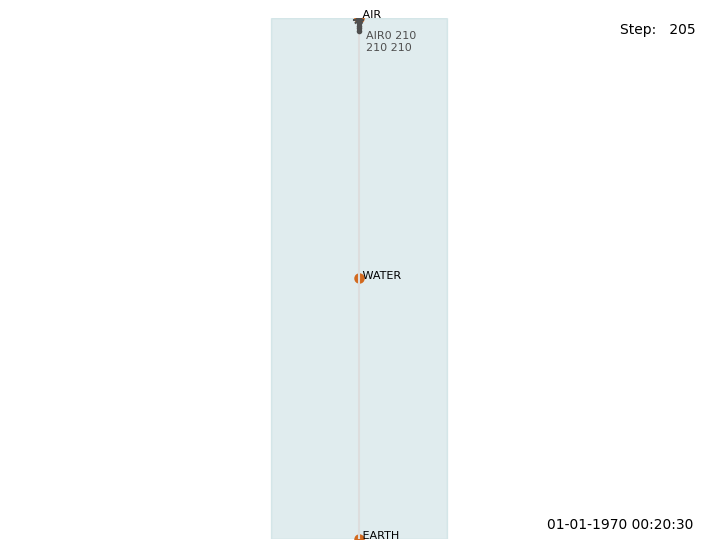

In [4]:
# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

#### Y Sector, 1 aircraft (Easy)

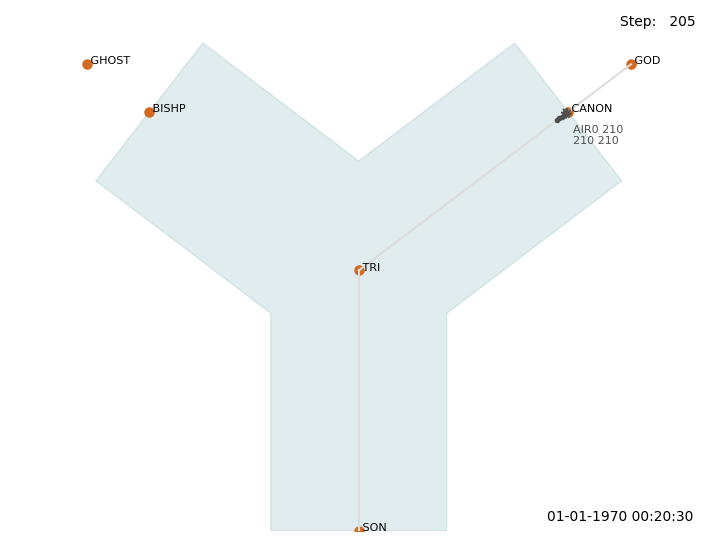

In [5]:
# instantiate a scenario
config = get_scenario_sector_y(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

#### Y Sector, 2 aircraft (Intermediate)

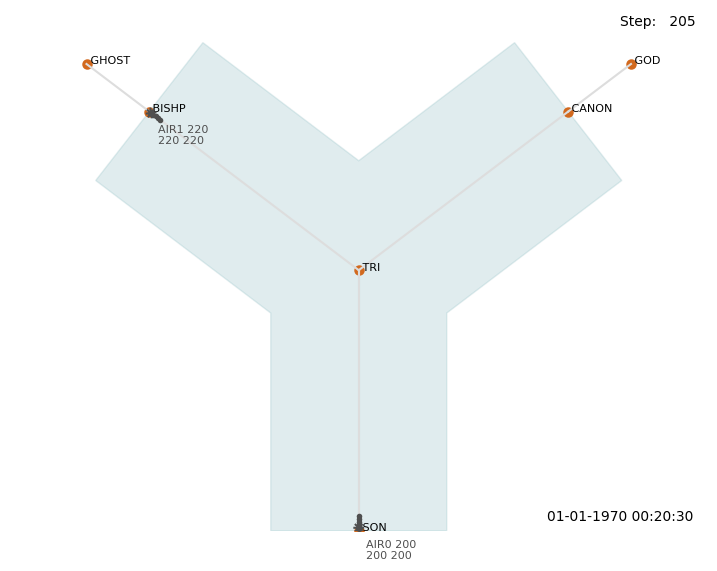

In [6]:
# instantiate a scenario
config = get_scenario_sector_y(DIFFICULTY_LEVEL_2, lateral_actions=True, vertical_actions=False)
env = SectorYEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 158
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

#### X Sector, 2 aircraft (Intermediate)

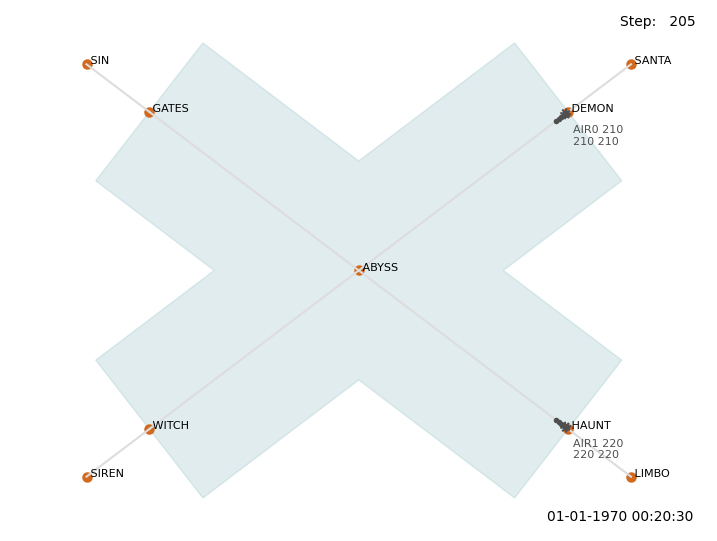

In [7]:
# instantiate a scenario
config = get_scenario_sector_x(DIFFICULTY_LEVEL_2, lateral_actions=True, vertical_actions=False)
env = SectorXEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

#### X Sector, 3-6 aircraft (Hard)

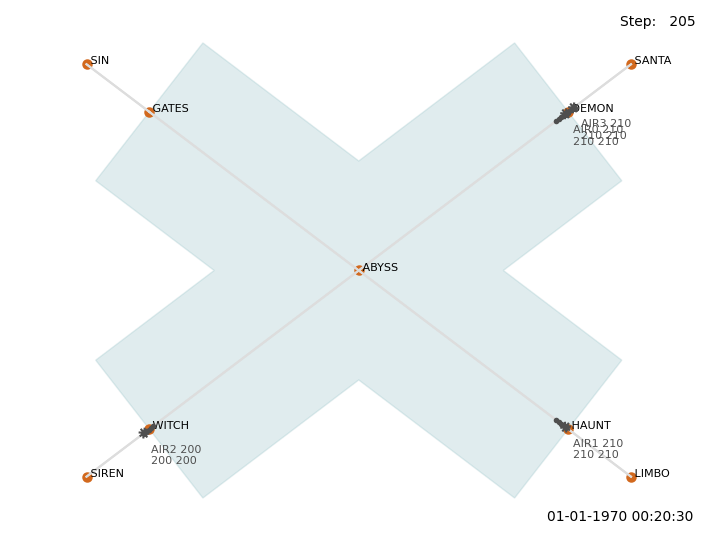

In [8]:
# instantiate a scenario
config = get_scenario_sector_x(DIFFICULTY_LEVEL_3, lateral_actions=True, vertical_actions=False)
env = SectorXEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 107
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

#### Springfield Sector

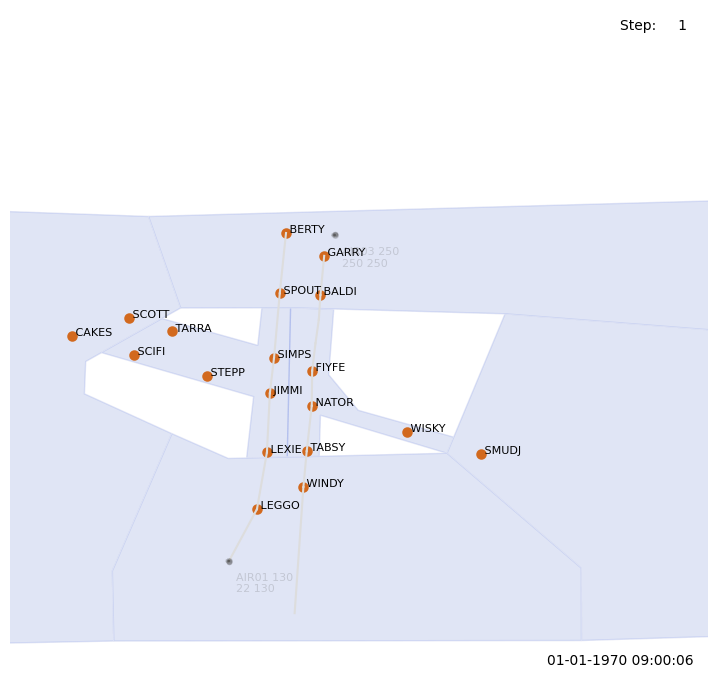

In [9]:
# instantiate a scenario
config = get_scenario_sector_springfield(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SpringfieldEnv(config=config)
env.set_render_mode("human")

# reset the fixed scenario
observation_dict, info_dict = env.reset()

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

### Infinite Scenario

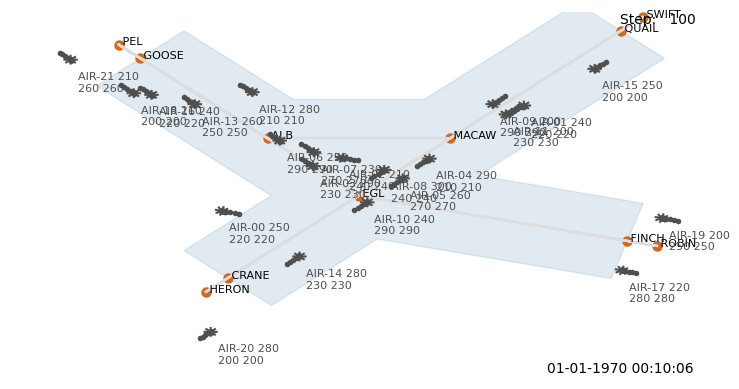

In [10]:
# instantiate a scenario
config = get_scenario_infinite("sector_xplus", lateral_actions=True, vertical_actions=False)
env = InfiniteEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
while not done:
    action = {} # empty `dict` means no action is taken for any aircraft.
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

### Sample Agents: Demo using I Sector Environment

In [11]:
# helper function
def plot_reward(rewards, agent_name="Agent"):
    ydata = []

    # for each time step, compute the average rewards across all aircraft.
    # note that you can compute the sum if you prefer that.
    for reward_dict in rewards:
        tmp = list(reward_dict.values())
        ydata.append(np.mean(tmp))

    xdata = np.arange(len(ydata))

    figure, ax  = plt.subplots()
    ax.plot(xdata, ydata)
    ax.set_title(f"{agent_name} performance by reward")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Reward")

    return figure, ax

#### Lazy Agent (does nothing)

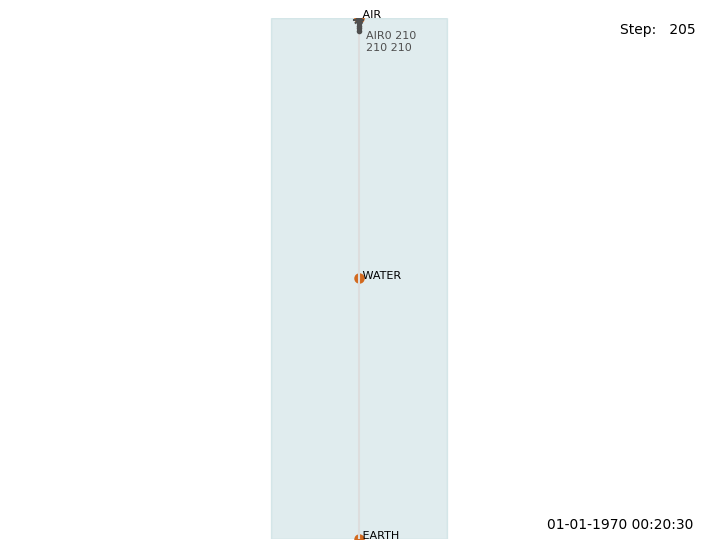

In [12]:
# Lazy Agent: an agent that chooses to do nothing at each time step
# in a scenario.
class LazyAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        GymActionsEnum = actions_to_enum(gym_env)
        # do nothing by taking the no operation (noop) action
        return {
            aircraft_id: GymActionsEnum.NOOP.value for aircraft_id in observation_dict.keys()
        }


# instantiate your favourite agent and run an evaluation
agent = LazyAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

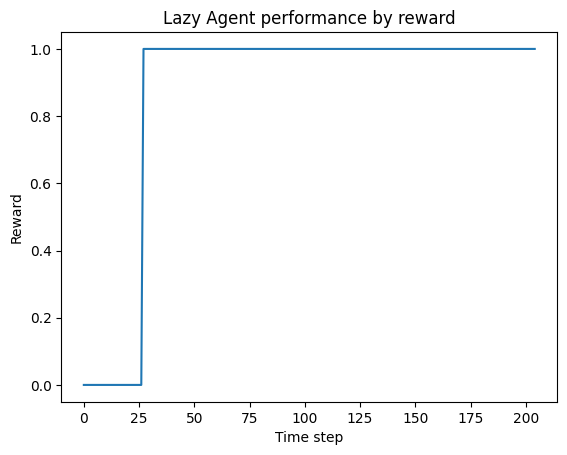

In [13]:
plot_reward(rewards, "Lazy Agent")
plt.show()

#### Turn Left Agent

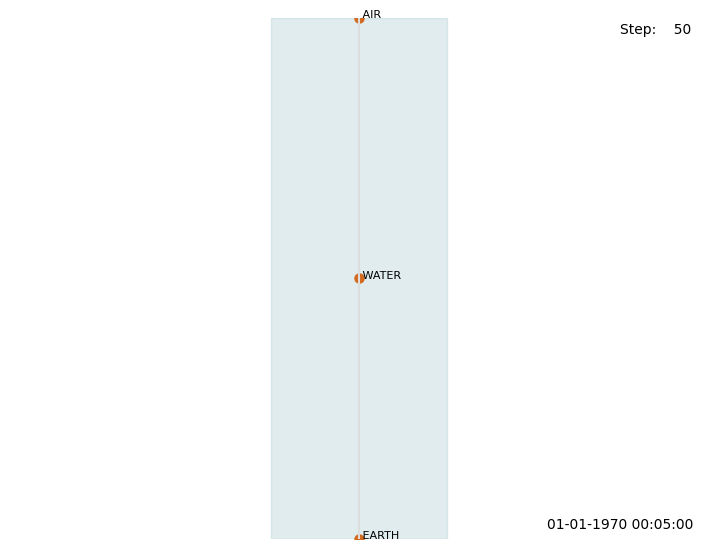

In [14]:
# TurnLeft Agent (a dummy agent): which always chooses
# the turn left (10 degrees) for an aircraft at every time step.
class TurnLeftAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        GymActionsEnum = actions_to_enum(gym_env)
        return {
            aircraft_id: GymActionsEnum.LEFT_10.value for aircraft_id in observation_dict.keys()
        }


# instantiate your favourite agent and run an evaluation
agent = TurnLeftAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

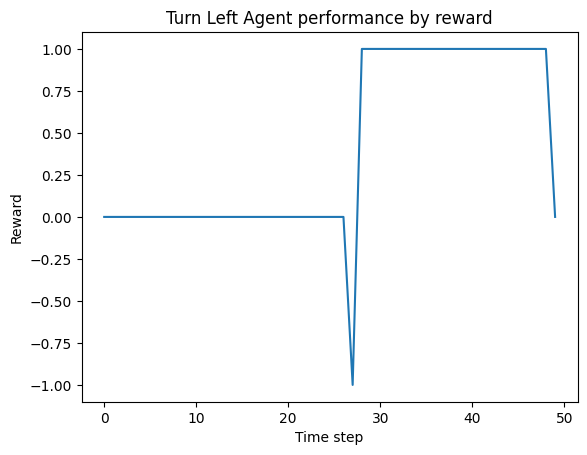

In [15]:
plot_reward(rewards, "Turn Left Agent")
plt.show()

#### Random Agent

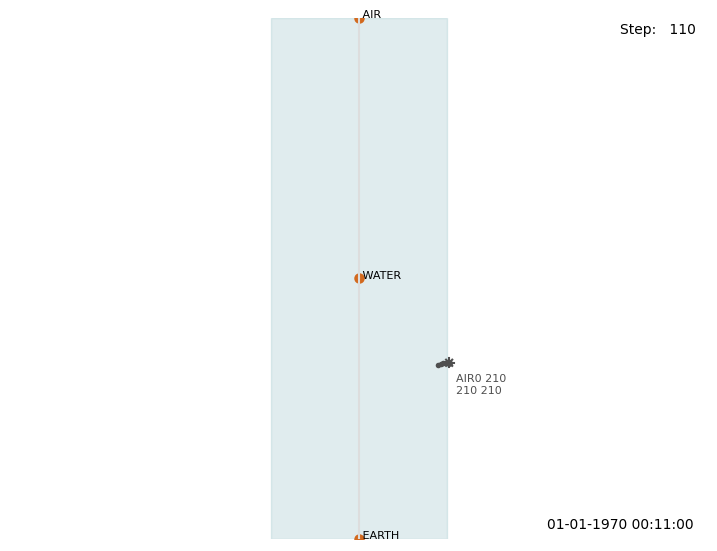

In [16]:
# Random Agent: which randomly samples
# an action to take at each time step.
class RandomAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        GymActionsEnum = actions_to_enum(gym_env)
        return {
            aircraft_id: random.choice(range(len(GymActionsEnum))) for aircraft_id in observation_dict.keys()
        }


# instantiate your favourite agent and run an evaluation
agent = RandomAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

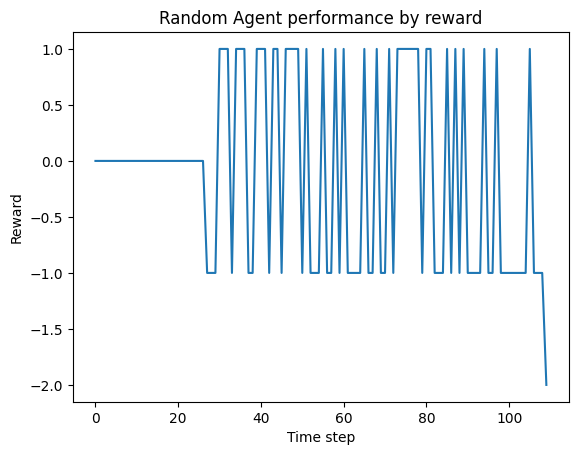

In [17]:
plot_reward(rewards, "Random Agent")
plt.show()

#### Rules-based Agent

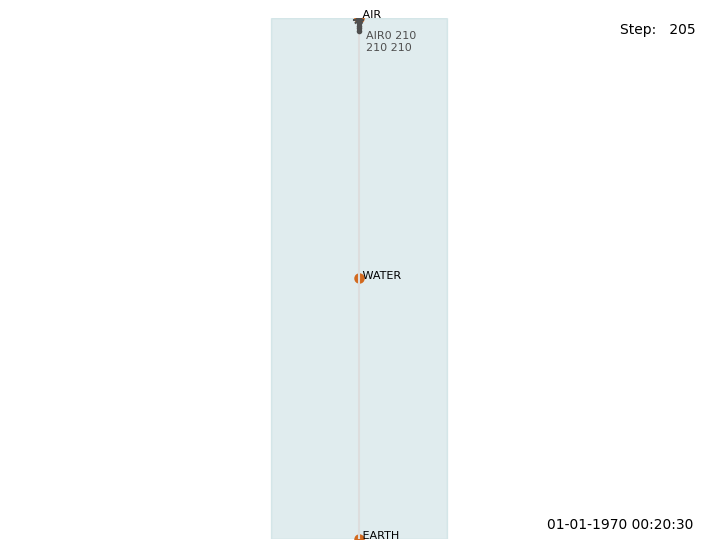

In [18]:
# Rules Agent: which randomly samples
# an action to take at each time step.
class RulesAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        # the rules-based agent might need direct access to the simulator
        # to get the raw information about each aircraft. get the simulator.
        simulator = info_dict["simulator_environment"]
        all_aircraft = simulator.aircraft # a `dict`

        # NOTE: given an aircraft id (also known as callsign) stored in a variable
        # called `aircraft_id`, the aircraft object in the simulator can be accessed via:
        # `all_aircraft[aircraft_id]`

        # implement the logic of your rules based agent here.
        # note that the current logic below choses the do nothing action (lazy agent).
        # deine your rules here, and change the code below to use your rules to process
        # the current state of the simulator and generate the action to take for each
        # aircraft.

        GymActionsEnum = actions_to_enum(gym_env)
        return {
            aircraft_id: GymActionsEnum.NOOP.value for aircraft_id in observation_dict.keys()
        }


# instantiate your favourite agent and run an evaluation
agent = RulesAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

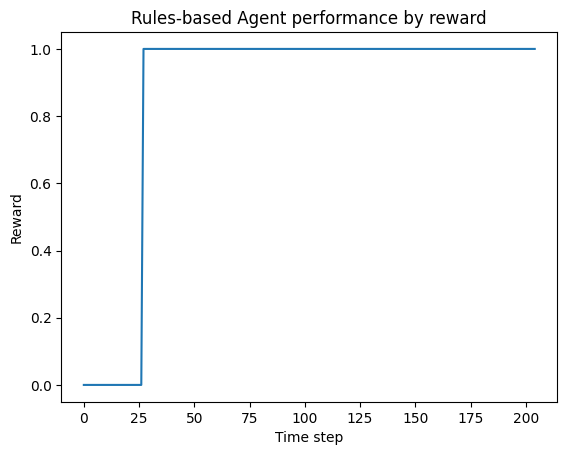

In [19]:
plot_reward(rewards, "Rules-based Agent")
plt.show()

#### Search Agent

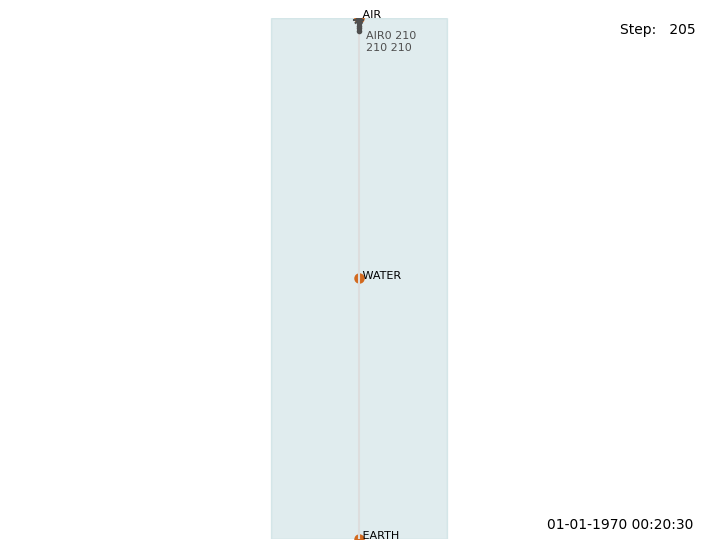

In [20]:
# Search Agent: which randomly samples
# an action to take at each time step.
class SearchAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        # the search agent might need direct access to the simulator
        # to get the raw information about each aircraft. get the simulator.
        simulator = info_dict["simulator_environment"]
        all_aircraft = simulator.aircraft # a `dict`

        # NOTE: given an aircraft id (also known as callsign) stored in a variable
        # called `aircraft_id`, the aircraft object in the simulator can be accessed via:
        # `all_aircraft[aircraft_id]`

        # implement your favourite tree search algorithm here (e.g., monte carlo tree search)
        # note that the current logic below choses the do nothing action (lazy agent).
        # deine your rules here, and change the code below to use your rules to process
        # the current state of the simulator and generate the action to take for each
        # aircraft.

        GymActionsEnum = actions_to_enum(gym_env)
        return {
            aircraft_id: GymActionsEnum.NOOP.value for aircraft_id in observation_dict.keys()
        }


# instantiate your favourite agent and run an evaluation
agent = SearchAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

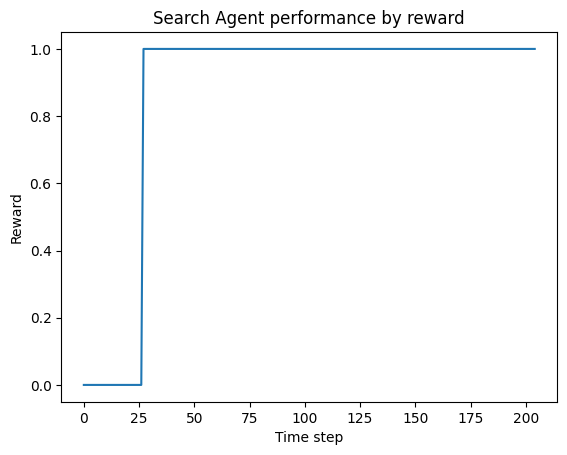

In [21]:
plot_reward(rewards, "Search Agent")
plt.show()

#### RL Agent

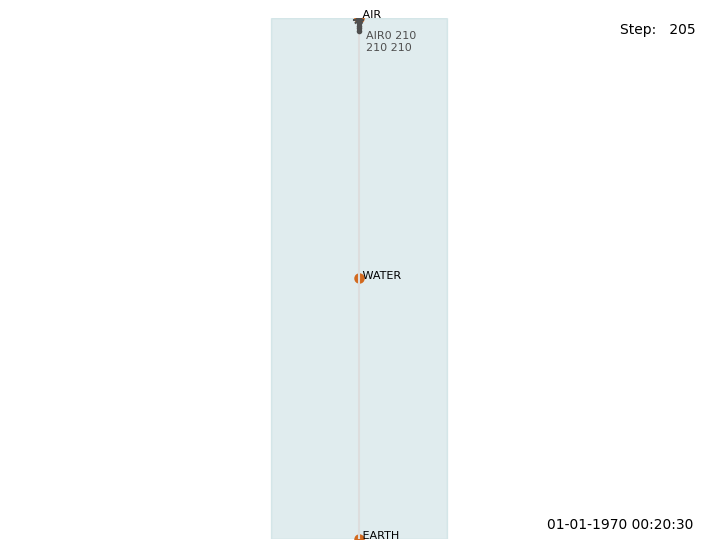

In [22]:
# Multi-agent deep RL setup:
# which uses multiple neural networks (one per aircraft/agent) to determine which action
# to chosen at each time step per aircraft.
# NOTE: the weights/parameters neural network needs to be
# trained using your favourite RL agorithm. This is done by
# replaying the scenario to the agent many times!
class RLAgent:
    def __init__(self):
        # define your neural network RL agent here (e.g., dqn, ppo)
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""
        # load your saved neural network that was previously trained
        # using `self.train(...)`. then use the network to process
        # the `observation` and generate the agent's action.

        # use your agent's neural network here to process `observation_dict` to get
        # actions for aircraft.
        # note that the current logic below choses the do nothing action (lazy agent).
        # change the code below to use your neural network.

        GymActionsEnum = actions_to_enum(gym_env)
        return {
            aircraft_id: GymActionsEnum.NOOP.value for aircraft_id in observation_dict.keys()
        }

    def train(self, gym_env):
        # implement your favourite RL algorithm here to
        # train a neural network (policy).
        # then save your trained network to file
        raise NotImplementedError

    def generate_sim_action(self, gym_env: BaseEnv) -> list:
        """Generate the sim action directly (bypassing gymnasium)"""

        # note used in RL
        pass

# instantiate your favourite agent and run an evaluation
agent = RLAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

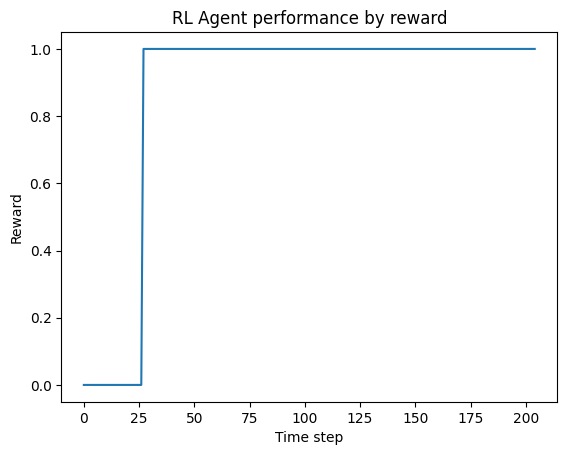

In [23]:
plot_reward(rewards, "RL Agent")
plt.show()

#### Any Other Agent

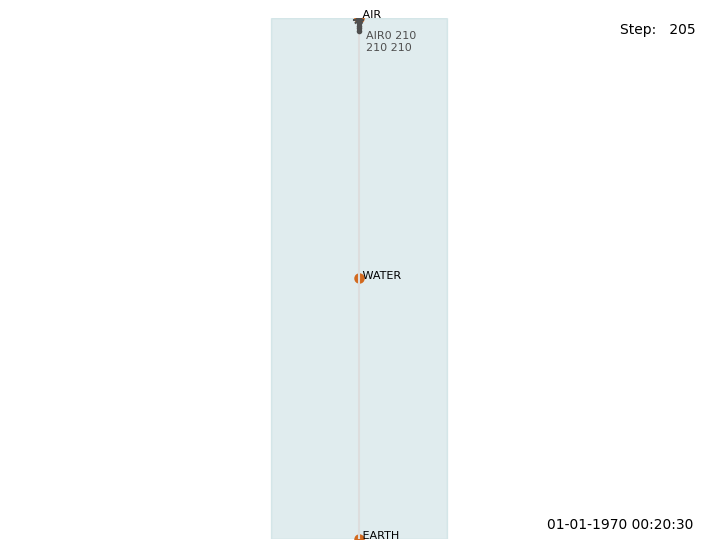

In [24]:
# Custom Agent: Define your own agent!
class CustomAgent:
    def __init__(self):
        pass

    def generate_action(
        self,
        gym_env: BaseEnv,
        observation_dict: dict[str, np.ndarray],
        info_dict: dict[str, object]
    ) -> dict[str, int]:
        """Generate a gymnasium formatted action"""

        # write your code here
        return {}

    def generate_sim_action(self, gym_env: BaseEnv) -> list:
        """Generate the sim action directly (bypassing gymnasium)"""

        # write your code here
        raise NotImplementedError

# instantiate your favourite agent and run an evaluation
agent = CustomAgent()

# instantiate a scenario
config = get_scenario_sector_i(DIFFICULTY_LEVEL_1, lateral_actions=True, vertical_actions=False)
env = SectorIEnv(config=config)
env.set_render_mode("human")

# reset the env with a seed to generate a reproducible scenario
seed = 100
observation_dict, info_dict = env.reset(seed=seed)

done = False
rewards = []
while not done:
    action = agent.generate_action(env, observation_dict, info_dict)
    observation_dict, reward_dict, done_dict, truncated_dict, info_dict = env.step(action)
    rewards.append(reward_dict)
    done = all(done_dict.values())

    # IPython.display.display(plt.gcf())
    IPython.display.display(env.radar.figure)
    IPython.display.clear_output(wait=True)

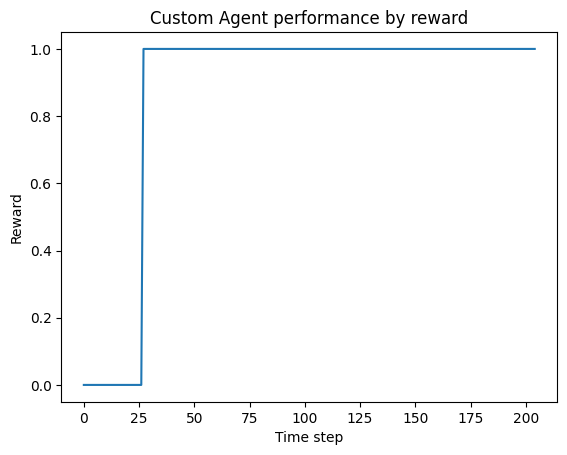

In [25]:
plot_reward(rewards, "Custom Agent")
plt.show()